# Road Risk and Claim Assessment

*Guardian Insurance Co. — Risk & Claims Strategy Team*

# Data Exploration

In [1]:
# Import required libraries and load the raw dataset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    df = pd.read_csv(
        'guardian-insurance-data.csv',
        sep=';',
        encoding='utf-8-sig',
        low_memory=False,
    )
except:
    df = pd.read_csv(
        'guardian-insurance-data.csv',
        sep=';',
        encoding='latin1',
        low_memory=False,
    )

In [2]:
# Display the first 5 rows of the dataset to inspect the structure
print('First 5 Rows')
display(df.head())

First 5 Rows


,Unnamed: 0,Record_ID,Data_Source,Severity,Incident_Start,Incident_End,Lat_Begin,Lng_Begin,Lat_End,Lng_End,...,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,Unnamed: 47
0,0,A-5818077,Source1,2.0,14/06/21 17:02,14/06/21 19:54,36.733629,-119.499021,36.733546,-119.497865,...,False,False,False,False,False,Day,Day,Day,Day,NaN
1,1,A-4539851,Source1,2.0,20:00.0,49:03.0,37.836539,-122.011617,37.848049,-122.027707,...,False,False,False,False,False,Day,Day,Day,Day,NaN
2,2,A-1264030,Source2,3.0,16/11/20 18:11,16/11/20 19:27,35.591496,-82.568298,NaN,NaN,...,False,False,False,False,False,Night,Night,Day,Day,NaN
3,3,A-5187515,Source1,2.0,04/09/22 10:25,04/09/22 11:44,38.797457,-121.882040,38.796722,-121.881355,...,False,False,False,False,False,Day,Day,Day,Day,NaN
4,4,A-1808663,Source3,2.0,08/11/19 06:05,08/11/19 07:05,37.776779,-122.236168,NaN,NaN,...,False,False,False,False,False,Night,Night,Day,Day,NaN


In [3]:
# Check dataset dimensions (total rows and columns)
print(f'Total Rows: {df.shape[0]}')
print(f'Total Columns: {df.shape[1]}')

Total Rows: 1048575
Total Columns: 48


In [4]:
# Display summary of column data types and non-null values
print(' Dataset Info ')
df.info()

 Dataset Info 
<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 48 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1048575 non-null  int64  
 1   Record_ID              1048575 non-null  str    
 2   Data_Source            996070 non-null   str    
 3   Severity               996070 non-null   float64
 4   Incident_Start         1048575 non-null  str    
 5   Incident_End           1048575 non-null  str    
 6   Lat_Begin              996070 non-null   float64
 7   Lng_Begin              996070 non-null   float64
 8   Lat_End                557591 non-null   float64
 9   Lng_End                557591 non-null   float64
 10  Distance(mi)           996070 non-null   float64
 11  Event_Summary          996068 non-null   str    
 12  Street_name            988641 non-null   str    
 13  City_name              990009 non-null   str    
 14  County        

# Data Cleaning

In [5]:
# Drop unnecessary index columns created during file loading
df = df.drop(columns=[col for col in df.columns if 'Unnamed' in col])

In [6]:
# Remove duplicate records to ensure data integrity
initial_rows = len(df)
df = df.drop_duplicates()
print(f"Removed {initial_rows - len(df)} duplicate rows.")

Removed 17594 duplicate rows.


In [7]:
# Convert start and end time columns to datetime format
df['Incident_Start'] = pd.to_datetime(df['Incident_Start'], format='mixed', errors='coerce')
df['Incident_End'] = pd.to_datetime(df['Incident_End'], format='mixed', errors='coerce')

# Drop rows where Incident_Start date conversion failed
df = df.dropna(subset=['Incident_Start'])

# Extract time components for trend analysis
df['Day_Name'] = df['Incident_Start'].dt.day_name()
df['Hour'] = df['Incident_Start'].dt.hour
df['Month'] = df['Incident_Start'].dt.month_name()
df['Month_Num'] = df['Incident_Start'].dt.month

print(f"Cleaned dataset total rows: {len(df)}")

Cleaned dataset total rows: 971588


## Feature Engineering: Season

In [8]:
# Derive Season from the incident month (meteorological seasons)
season_map = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3: 'Spring', 4: 'Spring', 5: 'Spring',
              6: 'Summer', 7: 'Summer', 8: 'Summer',
              9: 'Fall', 10: 'Fall', 11: 'Fall'}
df['Season'] = df['Month_Num'].map(season_map)
print(df['Season'].value_counts())

Season
Fall      285915
Winter    254858
Summer    218404
Spring    212411
Name: count, dtype: int64


## Fixing a Data-Type Issue

`df.info()` above shows `Temp(F)`, `Pressure(in)`, `Visibility(mi)` and `Wind_Speed(mph)` as **text (str)** instead of numeric — a few corrupted rows (`'error'` tokens in Pressure/Visibility, and a couple of misaligned rows where a wind-direction code like `'NW'` or a timestamp ended up in a numeric column) forced pandas to read the *whole column* as text.

In [9]:
# Fix incorrect data types on weather columns caused by a few corrupted rows
weather_numeric_cols = ['Temp(F)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)']
for col in weather_numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df[weather_numeric_cols].dtypes)

Temp(F)            float64
Pressure(in)       float64
Visibility(mi)     float64
Wind_Speed(mph)    float64
dtype: object


## Handling Missing Values

In [10]:
# Check missing value percentage per column
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_data = pd.DataFrame({'Missing Count': df.isnull().sum(), 'Percentage (%)': missing_percent})
missing_data[missing_data['Missing Count'] > 0].sort_values(by='Percentage (%)', ascending=False)

,Missing Count,Percentage (%)
Lng_End,479809,49.383998
Lat_End,479809,49.383998
Precipitation(in),329825,33.947002
WindChill(F),304370,31.327065
Wind_Speed(mph),124088,12.771669
Postal_ID,112410,11.569719
Visibility(mi),79221,8.153765
Pressure(in),74858,7.704706
Weather_Condition,74233,7.640378
Wind_Direction,74211,7.638114


In [11]:
# Fill missing categorical values with 'Unknown'
categorical_cols = df.select_dtypes(include=['object', 'string']).columns
df[categorical_cols] = df[categorical_cols].fillna('Unknown')

# Verify remaining missing values (numeric columns, handled next)
print("Remaining missing values count:", df.isnull().sum().sum())

Remaining missing values count: 2238472


In [12]:
# Drop rows with missing Severity instead of imputing it
before = len(df)
df = df.dropna(subset=['Severity'])
df['Severity'] = df['Severity'].astype(int)
print(f"Dropped {before - len(df)} rows with missing Severity.")

Dropped 48561 rows with missing Severity.


In [13]:
# Fill remaining missing numerical values with the median
# Severity is excluded (handled above). Lat_End/Lng_End are excluded too: imputing an
# accident's END coordinate with a median location would create geographically
# meaningless points, so we leave those as missing instead.
exclude_cols = ['Severity', 'Lat_End', 'Lng_End']
num_cols = [c for c in df.select_dtypes(include=['float64', 'int64']).columns if c not in exclude_cols]
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

print("Remaining missing numerical values:", df[num_cols].isnull().sum().sum())
print("Final cleaned shape:", df.shape)

Remaining missing numerical values: 0
Final cleaned shape: (923027, 51)


# Exploratory Data Analysis (EDA)

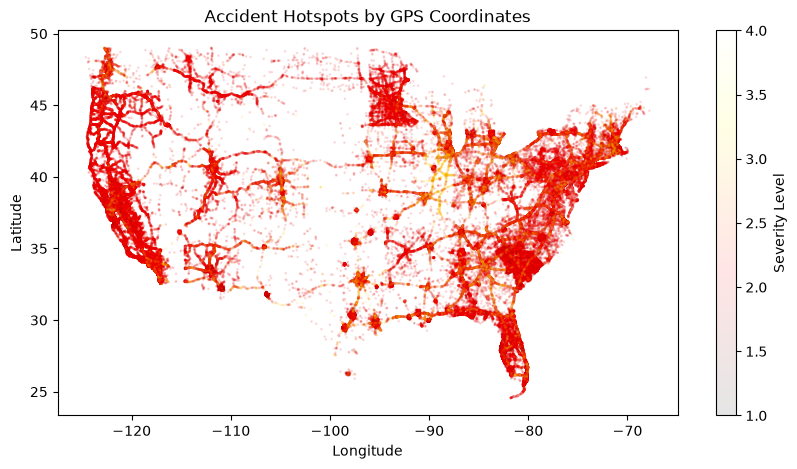

In [14]:
# Q1: Geographical accident hotspots using GPS coordinates
plt.figure(figsize=(10, 5))
plt.scatter(df['Lng_Begin'], df['Lat_Begin'], c=df['Severity'], cmap='hot', alpha=0.1, s=1)
plt.title('Accident Hotspots by GPS Coordinates')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar(label='Severity Level')
plt.show()

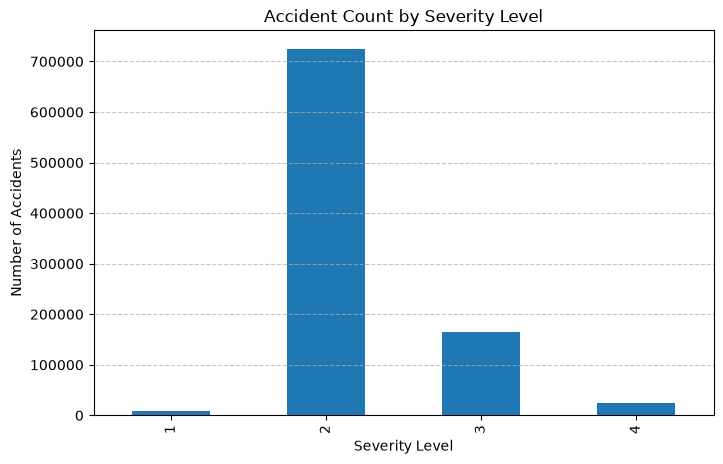

In [15]:
# Visualize the distribution of accident severity levels
plt.figure(figsize=(8, 5))
df['Severity'].value_counts().sort_index().plot(kind='bar', color='#1f77b4')
plt.title('Accident Count by Severity Level')
plt.xlabel('Severity Level')
plt.ylabel('Number of Accidents')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

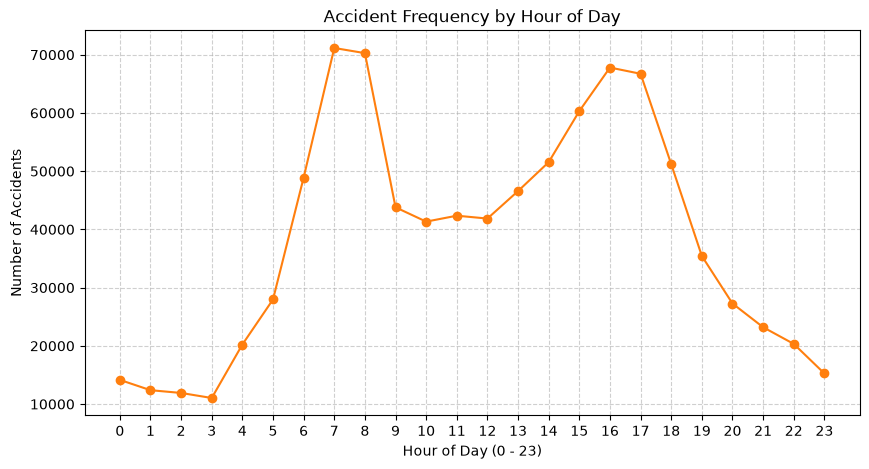

In [16]:
# Q2 / Q4: Visualize accidents trend across different hours of the day
plt.figure(figsize=(10, 5))
df['Hour'].value_counts().sort_index().plot(kind='line', marker='o', color='#ff7f0e')
plt.title('Accident Frequency by Hour of Day')
plt.xlabel('Hour of Day (0 - 23)')
plt.ylabel('Number of Accidents')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

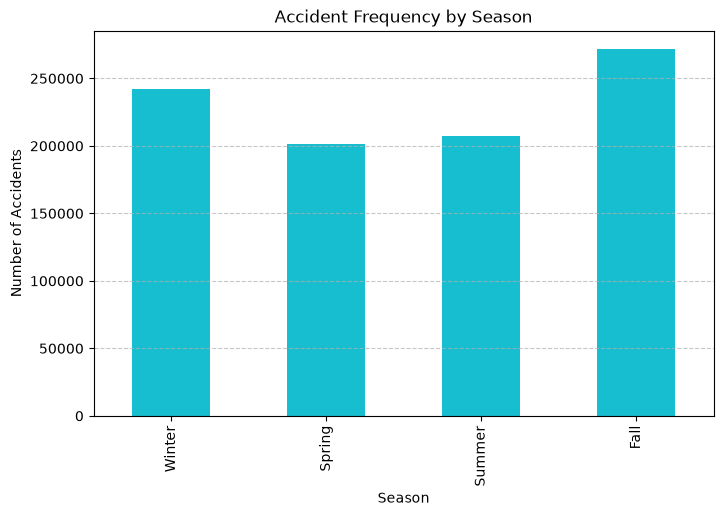

In [17]:
# Q2 (completion): accident frequency by season
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
plt.figure(figsize=(8, 5))
df['Season'].value_counts().reindex(season_order).plot(kind='bar', color='#17becf')
plt.title('Accident Frequency by Season')
plt.xlabel('Season')
plt.ylabel('Number of Accidents')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

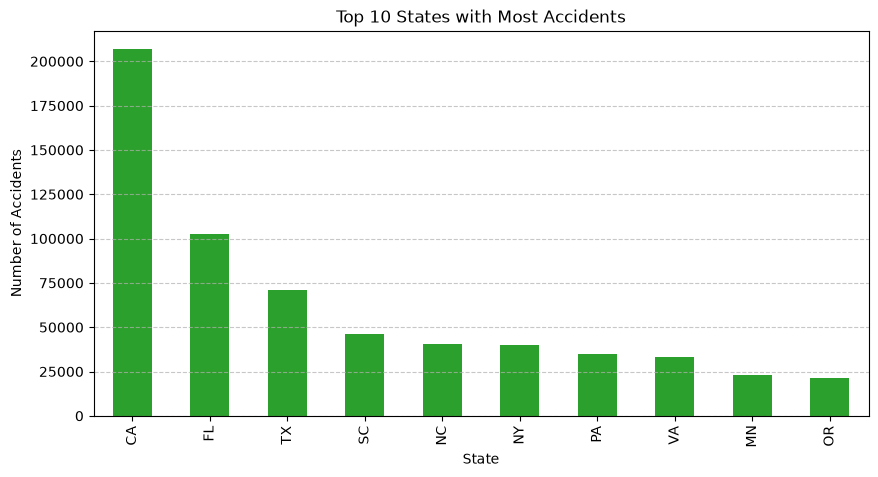

In [18]:
# Visualize the top 10 states with the highest number of accidents
plt.figure(figsize=(10, 5))
df['State'].value_counts().head(10).plot(kind='bar', color='#2ca02c')
plt.title('Top 10 States with Most Accidents')
plt.xlabel('State')
plt.ylabel('Number of Accidents')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

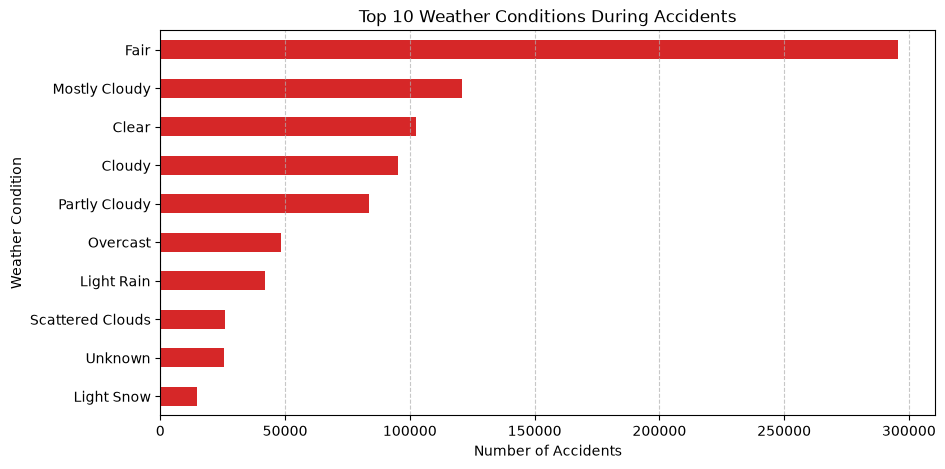

In [19]:
# Visualize accidents by weather conditions
plt.figure(figsize=(10, 5))
df['Weather_Condition'].value_counts().head(10).plot(kind='barh', color='#d62728').invert_yaxis()
plt.title('Top 10 Weather Conditions During Accidents')
plt.xlabel('Number of Accidents')
plt.ylabel('Weather Condition')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Q3: Speed / Speed Limit Impact — Data Limitation

**This dataset does not contain a `Speed` or `Speed_Limit` column**, so Q3 cannot be answered directly — this should be stated to stakeholders rather than skipped silently. As the closest available proxy, `Distance(mi)` (the length of road affected by the incident) tends to run higher on high-speed roads (highways) than on low-speed city streets, so we use it as an indirect signal.

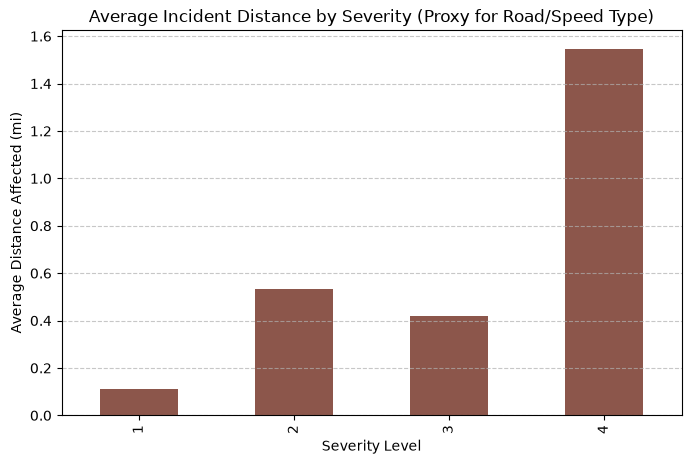

In [20]:
# Q3: Speed / Speed Limit Impact (proxy analysis — see note above)
plt.figure(figsize=(8, 5))
df.groupby('Severity')['Distance(mi)'].mean().plot(kind='bar', color='#8c564b')
plt.title('Average Incident Distance by Severity (Proxy for Road/Speed Type)')
plt.xlabel('Severity Level')
plt.ylabel('Average Distance Affected (mi)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

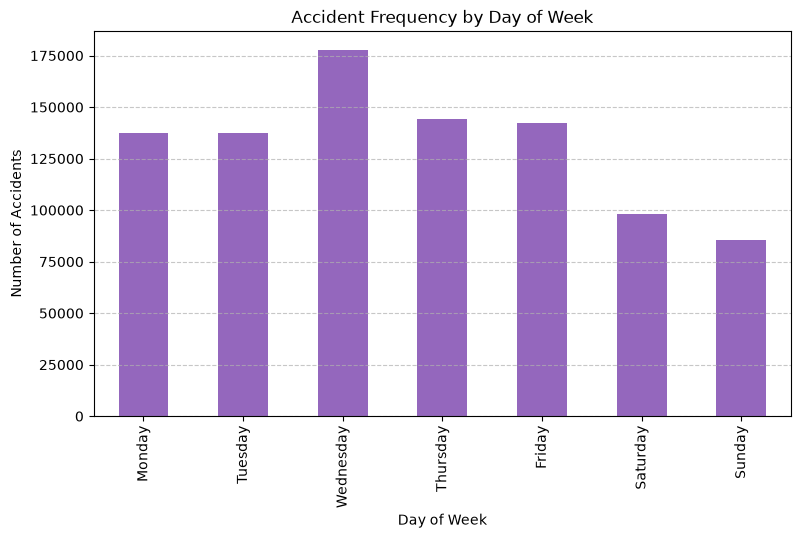

In [21]:
# Q2 / Q4: Visualize accidents trend across days of the week
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(9, 5))
df['Day_Name'].value_counts().reindex(days_order).plot(kind='bar', color='#9467bd')
plt.title('Accident Frequency by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Accidents')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Q4 (completion): do peak hours shift across days?

The hour chart and day chart above show each pattern separately, but not how they interact. The heatmap below answers the actual question: which hours are worst, **and does that change depending on the day**?

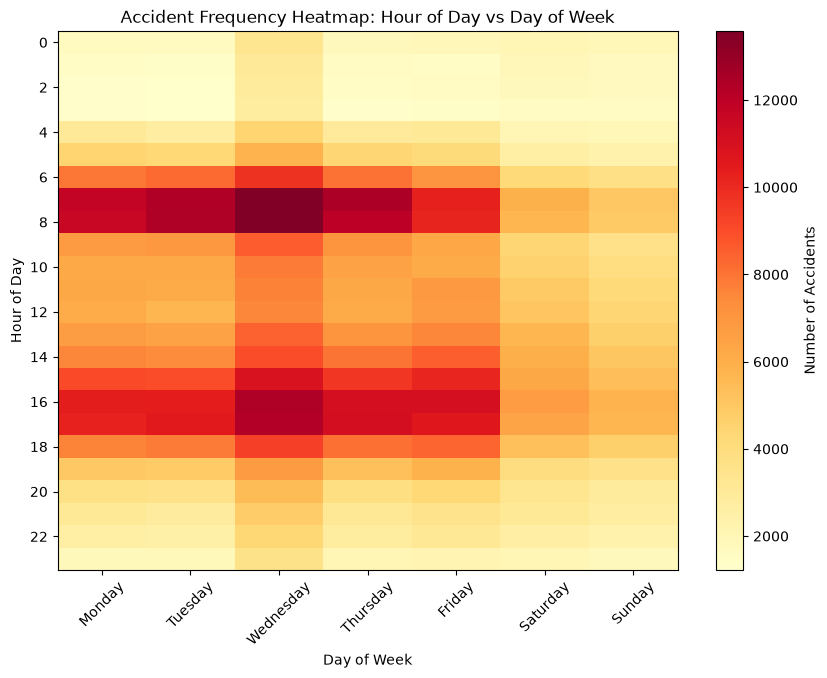

In [22]:
# Q4: combined Hour x Day heatmap
pivot = df.pivot_table(index='Hour', columns='Day_Name', values='Record_ID', aggfunc='count')
pivot = pivot[days_order]

plt.figure(figsize=(10, 7))
plt.imshow(pivot, aspect='auto', cmap='YlOrRd')
plt.colorbar(label='Number of Accidents')
plt.xticks(range(len(days_order)), days_order, rotation=45)
plt.yticks(range(0, 24, 2), range(0, 24, 2))
plt.title('Accident Frequency Heatmap: Hour of Day vs Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Hour of Day')
plt.show()

<Figure size 800x500 with 0 Axes>

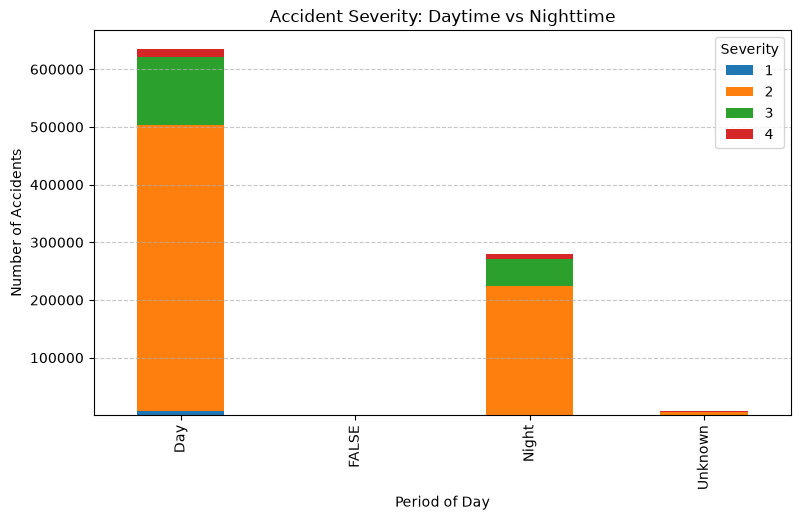

In [23]:
# Q5: Day vs Night Severity Analysis
plt.figure(figsize=(8, 5))
df.groupby(['Sunrise_Sunset', 'Severity']).size().unstack().plot(kind='bar', stacked=True, figsize=(9, 5))
plt.title('Accident Severity: Daytime vs Nighttime')
plt.xlabel('Period of Day')
plt.ylabel('Number of Accidents')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

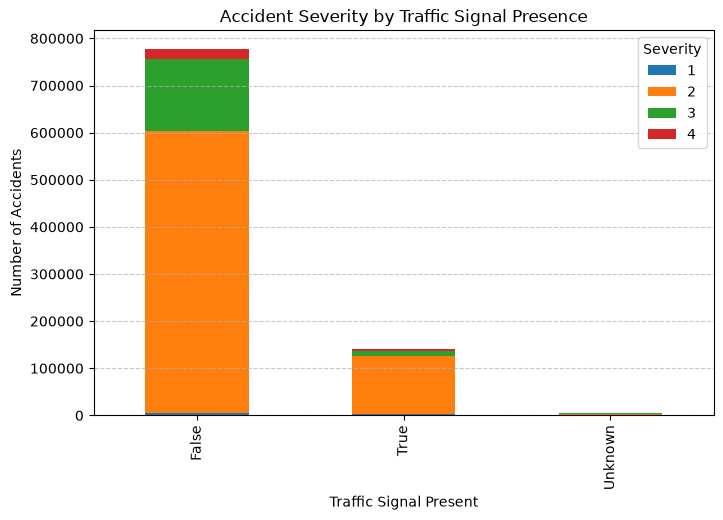

In [24]:
# Impact of traffic signals on accident severity
df.groupby(['Traffic_Signal', 'Severity']).size().unstack().plot(kind='bar', stacked=True, figsize=(8, 5))
plt.title('Accident Severity by Traffic Signal Presence')
plt.xlabel('Traffic Signal Present')
plt.ylabel('Number of Accidents')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

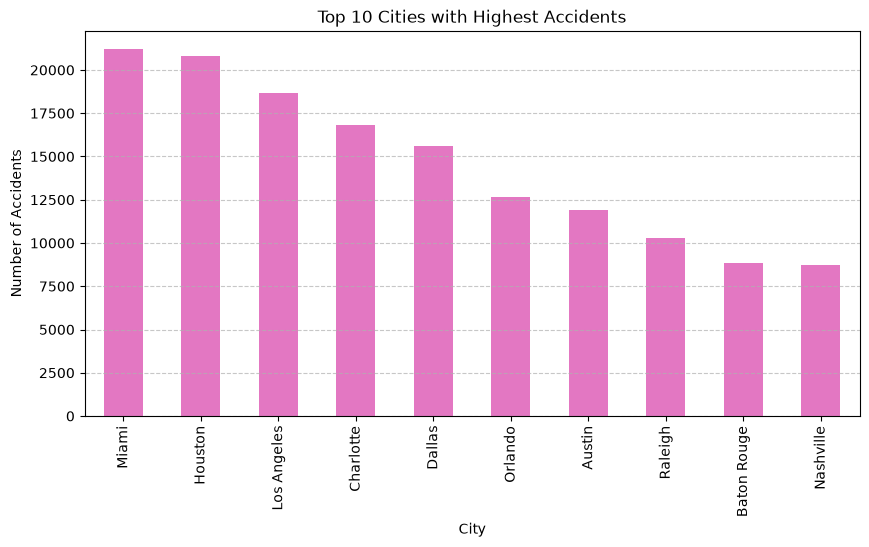

In [25]:
# Q6: Top 10 Cities by Accident Volume
plt.figure(figsize=(10, 5))
df['City_name'].value_counts().head(10).plot(kind='bar', color='#e377c2')
plt.title('Top 10 Cities with Highest Accidents')
plt.xlabel('City')
plt.ylabel('Number of Accidents')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Q6 (completion): severity, not just volume

The chart above ranks cities by accident *count*. The question also asks about *severity levels*, so here's average severity for those same top-10 cities.

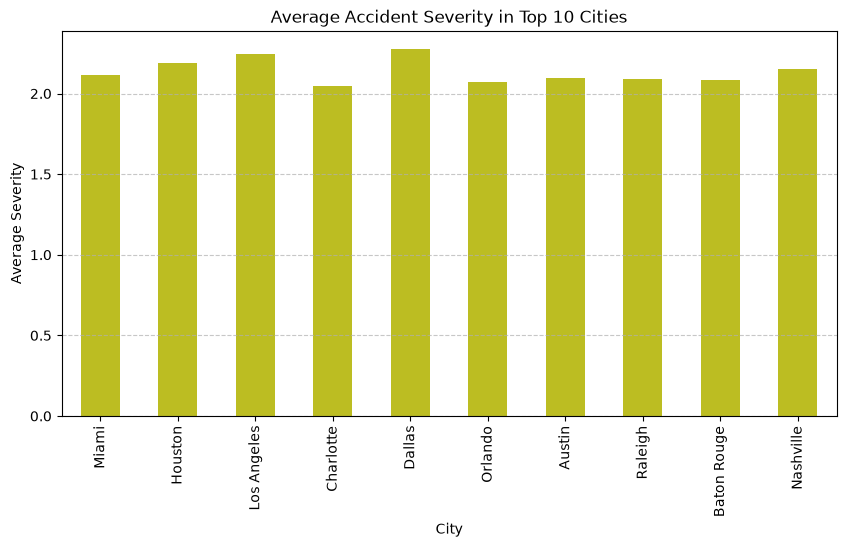

In [26]:
# Q6: average severity for the top 10 cities by accident volume
top_cities_idx = df['City_name'].value_counts().head(10).index
city_severity = df[df['City_name'].isin(top_cities_idx)].groupby('City_name')['Severity'].mean().reindex(top_cities_idx)

plt.figure(figsize=(10, 5))
city_severity.plot(kind='bar', color='#bcbd22')
plt.title('Average Accident Severity in Top 10 Cities')
plt.xlabel('City')
plt.ylabel('Average Severity')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Key Findings & Recommendations

### Key Insights & Risk Factors

* **Peak Hours:** Accidents sharply peak during morning rush hours (7:00 AM - 8:00 AM) and evening commute hours (4:00 PM - 5:00 PM).
* **Peak hours shift by day:** the Hour x Day heatmap shows the rush-hour peaks are a weekday pattern — weekends are flatter with a later, milder midday bump. A pricing or campaign rule built only on "7-8 AM and 4-5 PM" would over-penalize weekend driving.
* **Geographic Concentration:** California (CA) shows the highest accident frequency by a significant margin compared to other states.
* **Weather Conditions:** Contrary to expectation, the vast majority of accidents occur during clear/fair weather, suggesting human factors (speeding, distraction) outweigh weather risks.
* **Weekly Pattern:** Accident rates are consistently higher during weekdays compared to weekends.
* **Seasonality:** Fall has the highest accident volume, followed by Winter — both meaningfully above Spring and Summer. Daylight-saving clock changes and wetter/darker conditions in Fall and Winter are a plausible driver worth investigating further.
* **Speed (limitation):** the dataset has no Speed or Speed Limit field, so Q3 cannot be answered directly. As a proxy, average incident Distance(mi) is roughly 3x higher for Severity 4 than Severity 1, hinting that higher-speed roads (highways) are tied to more severe — if less frequent — incidents. This should be flagged to stakeholders as a data gap, not silently skipped.
* **Infrastructure & Environmental Impact:** Most accidents occur in areas without traffic signals and during daytime hours. However, high-severity accidents remain present, with major urban centers like Miami, Houston, and Los Angeles representing the primary hotspots.
* **City severity vs. volume:** the cities with the most accidents are not the ones with the highest *average* severity. Dallas and Los Angeles post the highest average severity among the top-10 cities by volume, while Charlotte, despite high volume, has the lowest average severity of the group — count and severity need to be priced separately, not treated as the same risk signal.

### Strategic Recommendations for Risk Assessment

1. **Dynamic Premium Pricing:** Adjust insurance premiums based on peak travel hours and high-risk states like California, using the hour x day pattern (not a flat rush-hour rule) so weekend driving isn't over-penalized.
2. **Behavioral Telematics:** Reward policyholders who avoid driving during high-risk weekday rush hours (7-8 AM & 4-5 PM).
3. **Safety Awareness Campaigns:** Focus awareness efforts on commuter distraction rather than strictly adverse weather conditions, with extra emphasis heading into Fall/Winter.
4. **Underwriting by city:** use average severity, not just accident count, when scoring city-level risk — high-volume cities like Charlotte are not necessarily high-severity.
5. **Close the data gap:** request Speed/Speed Limit data (or road-classification data) from traffic authorities for the next collection cycle, since Q3 could only be answered indirectly with the current dataset.

---
## Interactive Dashboard

A companion interactive dashboard (HTML) was built from this cleaned dataset with filters by state, weather and time period, a hotspot map, and the same KPIs above in one view for stakeholders who prefer to explore the data themselves rather than read a static report.